# **BAT-BALL-COLLISION ANALYSIS** 

### Notebook Summary

This notebook simulates and analyzes the vibrational dynamics of a baseball bat modeled as a non-uniform Timoshenko beam. The workflow proceeds as follows:

1. **Setup & Static Bat** — Load the bat geometry (R161 profile), set material properties ($\rho$, $Y$, $S$), and visualize the static bat profile as a series of rectangular cross-sectional slices.

2. **Eigenmode Analysis** — Compute and inspect the eigenvalues/eigenvectors of the system matrix $H$, identify stable vs. unstable modes, locate vibrational nodes along the bat, and plot the first 10 mode shapes with their natural frequencies.

3. **Mode Filtering** — Project initial conditions onto the stable eigensubspace and reconstruct a filtered $H$ matrix to ensure numerical stability during integration.

4. **Free Vibration Integration** — Solve the coupled ODE system $\ddot{\psi} = H\psi$ using RK45, starting from a small initial displacement at a chosen impact point (slice 75). Visualize the resulting displacement $y(t,z)$ and rotation $\Phi(t,z)$ fields as heatmaps.

5. **Fourier Analysis** — Compute the FFT of the displacement solution along the time axis, extract the amplitude spectrum, and identify resonant frequencies via peak-finding. Compare recovered frequencies against Alan Nathan's reference values.

6. **Animation** — Generate `.mp4` animations of the bat oscillation at various exaggeration factors.

7. **Forced Collision** — Apply an external force profile (constant pulse or Gaussian) at the impact location and integrate the forced ODE $\ddot{\psi} = H\psi + F(t)$ to simulate a ball–bat collision.

## **Imports**

In [1]:
from bat_class import BatOsc
import numpy as np
import matplotlib.pyplot as plt
import os
from create_system_matrix import create_system_matrices, load_H_matrix
from scipy.integrate import solve_ivp
from plot_osc import rotate, make_box
from scipy.optimize import curve_fit
from scipy.linalg import eig
from scipy.signal import find_peaks
from plot_osc import plot_bat_disp
import pandas as pd

In [2]:
#%% PLOT SETTINGS
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'lines.linewidth': 2,
    'lines.markersize': 6,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'grid.alpha': 0.3,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'figure.dpi': 150,
    'axes.facecolor': '#F1F5F2',
    'axes.grid': True
})

colors = plt.get_cmap('tab10').colors
#turn colors into a list
colors = [colors[i] for i in range(len(colors))]
colors = ['#EFA00B', '#439775', '#4B4E6D', '#6A4C93', '#FAC8CD', '#9BC1BC', '#5D737E', '#D9BF77', '#ACD8AA', '#FFE156']

## **Static Bats**

### Set Up System ###

In [5]:
#bat parameters- standard
bat_prof_s = np.loadtxt('data/r161.dat')
bat_length_s = 0.84 #in m
mass_s = 0.885 # in kg
rho_s = 649 # in kg/m^3
Y_s = 1.814 * 1e10 # in N/m^2
S_s = 1.05 * 1e9 # in N/m^2

#bat parameters- torpedo
bat_prof_t = np.loadtxt('data/torpedo.dat')
rho_t = 690 # in kg/m^3
Y_t = 1.65e10 # in N/m^2
S_t = 0.9e9 # in N/m^2
mass_t = 0.907 # in kg (32 oz converted to kg)

In [7]:
standard_bat = BatOsc(bat_prof_s, 0.01) # initialize bat with dz = 0.01 m
standard_bat.set_bat_features(mass_s, rho_s, Y_s, S_s) # in kg, kg/m^3, N/m^2, N/m^2, setting the bat features for integration

torpedo_bat = BatOsc(bat_prof_t, 0.01) # initialize bat with dz = 0.01 m
torpedo_bat.set_bat_features(mass_t, rho_t, Y_t, S_t) # in kg, kg/m^3, N/m^2, N/m^2, setting the bat features for integration


No solution found, plotting static bat.


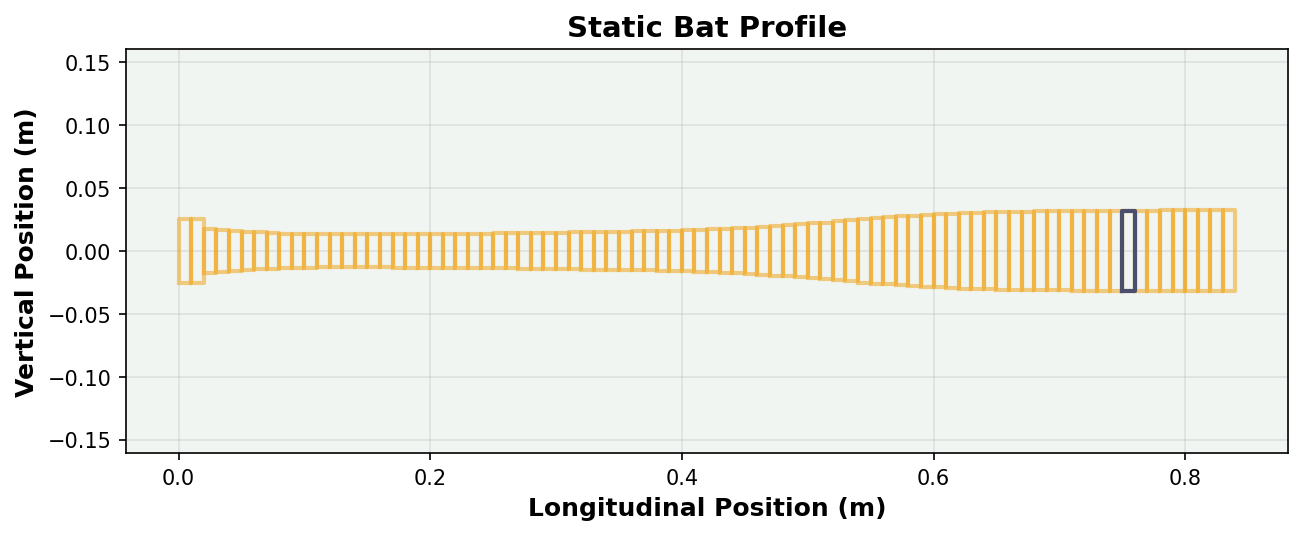

No solution found, plotting static bat.


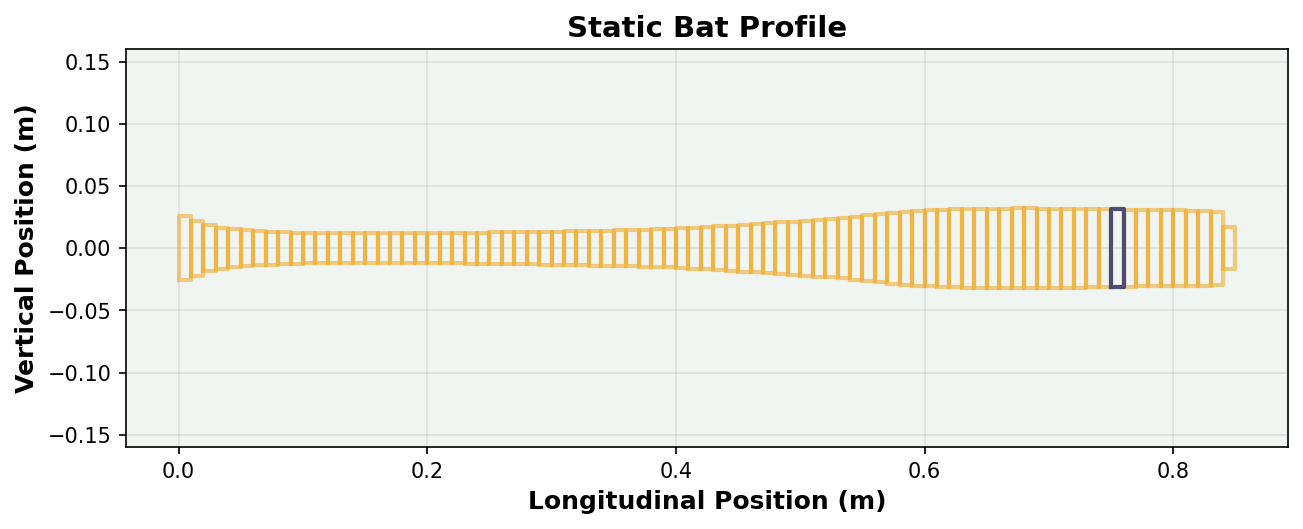

In [10]:
impact_idx = 75
standard_bat.plot_bat(highlight = impact_idx)
torpedo_bat.plot_bat(highlight = impact_idx)

In [11]:
y0 = np.zeros(standard_bat.N)
Phi0 = np.zeros(standard_bat.N)
dy0 = np.zeros(standard_bat.N)
dPhi0 = np.zeros(standard_bat.N)

#set init displacement
y0[impact_idx] = 0.0001 

psi0 = np.concatenate((y0, Phi0, dy0, dPhi0))
standard_bat.set_initial_conditions(psi0)
standard_bat.get_H_matrix('data/H_matrix_Alan.csv')
# standard_bat.get_H_matrix()
#4th order yoshida

In [9]:
end_t = 0.5 # end time for integration in seconds
t_eval = np.linspace(0, end_t, 10000) # time evaluation points for integration


### Examine Eigenmodes ###

In [ ]:
#re-set up matrix
df = pd.read_csv('data/H_matrix_Alan.csv')
H = np.zeros((2*standard_bat.N, 2*standard_bat.N))
for row in df.itertuples():
    H[row.i - 1, row.j - 1] = row._3

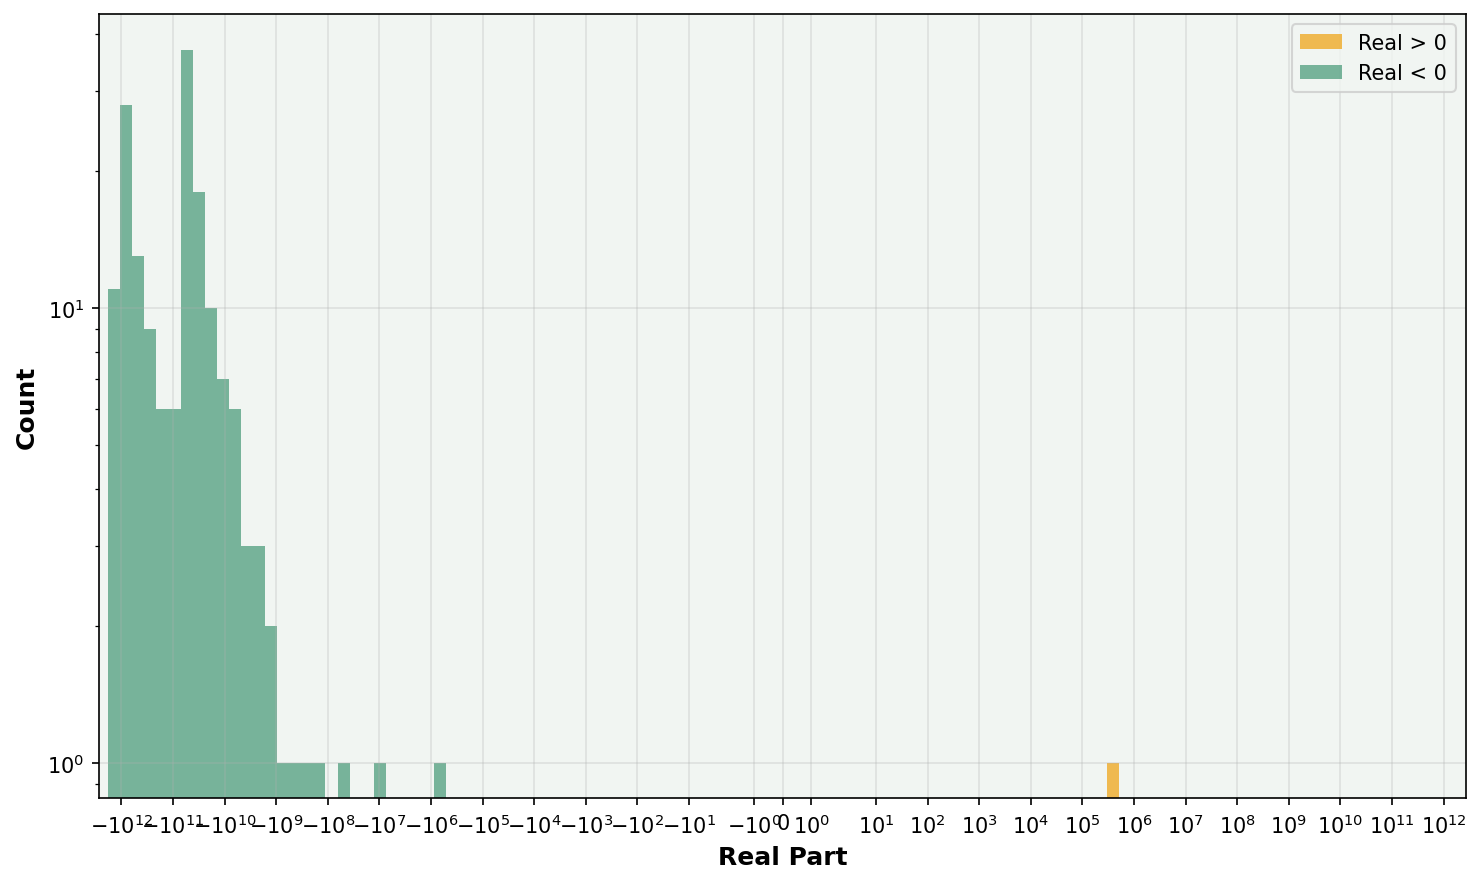

In [ ]:
#hist of the H matrix eigvals for real and imaginary parts, log scale with even bins in log space
H_eigvals = np.linalg.eigvals(standard_bat.H)

fig, ax1 = plt.subplots(1, 1, figsize=(10, 6), sharex=True)

# Collect all nonzero magnitudes to determine shared symmetric x-limits
all_vals = np.concatenate([H_eigvals.real, H_eigvals.imag])
nonzero = np.abs(all_vals[all_vals != 0])
if len(
    nonzero) > 0:
    shared_max = nonzero.max() * 1.5
else:
    shared_max = 1.0

# Real part: log-spaced bins for positive and negative values separately
real_vals = H_eigvals.real
real_pos = real_vals[real_vals > 0]
real_neg = real_vals[real_vals < 0]

# Compute shared bin range from both sides so bins are symmetrical
all_abs = np.abs(real_vals[real_vals != 0])
shared_min = all_abs.min()
shared_bin_max = all_abs.max()
bins_log = np.logspace(np.log10(shared_min), np.log10(shared_bin_max), 30)
bins_pos = bins_log
bins_neg = -bins_log[::-1]

if len(real_pos) > 0:
    ax1.hist(real_pos, bins=bins_pos, alpha=0.7, label='Real > 0', color=colors[0])
if len(real_neg) > 0:
    ax1.hist(real_neg, bins=bins_neg, alpha=0.7, label='Real < 0', color=colors[1])
ax1.set_xscale('symlog')
ax1.set_xlabel('Real Part')
ax1.set_ylabel('Count')
ax1.set_xlim(-shared_max, shared_max)
ax1.legend()
ax1.set_yscale('log')

plt.tight_layout()
plt.show()

In [12]:
# are any eigvals with positive real part? If so, how many?
num_unstable = np.sum(H_eigvals.real > 0)
print(f'Number of eigenvalues with positive real part: {num_unstable}')
for num in range(num_unstable):
    print(f'Unstable eigenvalue {num+1}: {H_eigvals[H_eigvals.real > 0][num]:.2e}')

Number of eigenvalues with positive real part: 2
Unstable eigenvalue 1: 2.96e+05
Unstable eigenvalue 2: 4.80e+05


In [13]:
#Which eigenvalues have the largest imaginary part? Plot those modes.
num_modes_to_plot = 5
largest_imag_indices = np.argsort(np.abs(H_eigvals.imag))[-num_modes_to_plot:]
largest_imag_eigvals = H_eigvals[largest_imag_indices]
print("Eigenvalues with largest imaginary part:")
for idx, eigval in zip(largest_imag_indices, largest_imag_eigvals):
    print(f"Index: {idx}, Eigenvalue: {eigval:.4e}")

Eigenvalues with largest imaginary part:
Index: 58, Eigenvalue: -2.4503e+11
Index: 59, Eigenvalue: -2.2810e+11
Index: 60, Eigenvalue: -2.1318e+11
Index: 52, Eigenvalue: -3.5235e+11
Index: 167, Eigenvalue: -4.6789e+10


In [ ]:
evals, evecs = np.linalg.eig(standard_bat.H)
omega = np.sqrt(-evals[evals < 0]) / (2 * np.pi) # convert to frequencies in Hz
#mutually sort eigvecs and eigvals by frequency
for i in range(len(omega)):
    for j in range(i+1, len(omega)):
        if omega[i] > omega[j]:
            # Swap frequencies
            omega[i], omega[j] = omega[j], omega[i]
            # Swap corresponding eigenvectors
            evecs[:, [i, j]] = evecs[:, [j, i]]
print("First 10 frequencies (Hz):", omega[:10])

First 10 frequencies (Hz): [ 145.29829924  566.9072958  1175.38586741 1844.87957169 2575.97282268
 3357.50531566 4162.47746106 4973.36775294 5793.37573033 6607.30948896]


In [ ]:
#find zeros of the modes to find nodes
num_modes = 10
nodes = []
tol = 5e-3
for i in range(num_modes):
    y = evecs[:, i].real[:standard_bat.N]
    sign_changes = np.where(np.diff(np.sign(y)))[0]
    print(sign_changes)
    roots = []

    for i in sign_changes:
        # linear interpolation
        x0, x1 = standard_bat.zs[i], standard_bat.zs[i+1]
        y0, y1 = y[i], y[i+1]
        root = x0 - y0*(x1-x0)/(y1-y0)
        roots.append(np.round(root *1e2, 0)) # convert to cm
    roots = np.array(roots, dtype = int)
    nodes.append(roots)
    print(f"Mode {i} has nodes at : {roots}")

[36]
Mode 36 has nodes at : [37]
[ 6 38 71]
Mode 71 has nodes at : [ 7 39 72]
[ 4 23 49 73]
Mode 73 has nodes at : [ 5 25 50 75]
[ 3 18 35 55 75]
Mode 75 has nodes at : [ 4 20 37 57 76]
[ 2 15 29 43 60 76]
Mode 76 has nodes at : [ 4 16 30 45 62 78]
[ 2 13 24 36 49 63 77]
Mode 77 has nodes at : [ 3 14 26 38 51 65 79]
[ 2 11 21 31 42 54 66 78]
Mode 78 has nodes at : [ 3 13 23 33 44 55 68 80]
[ 1 10 19 28 37 47 57 68 79]
Mode 79 has nodes at : [ 3 11 20 29 39 48 59 70 80]
[ 1  9 17 25 33 42 51 60 70 79]
Mode 79 has nodes at : [ 3 10 19 27 35 43 52 62 71 81]
[ 1  8 16 23 30 38 46 54 62 71 80]
Mode 80 has nodes at : [ 2 10 17 24 32 39 47 56 64 73 81]


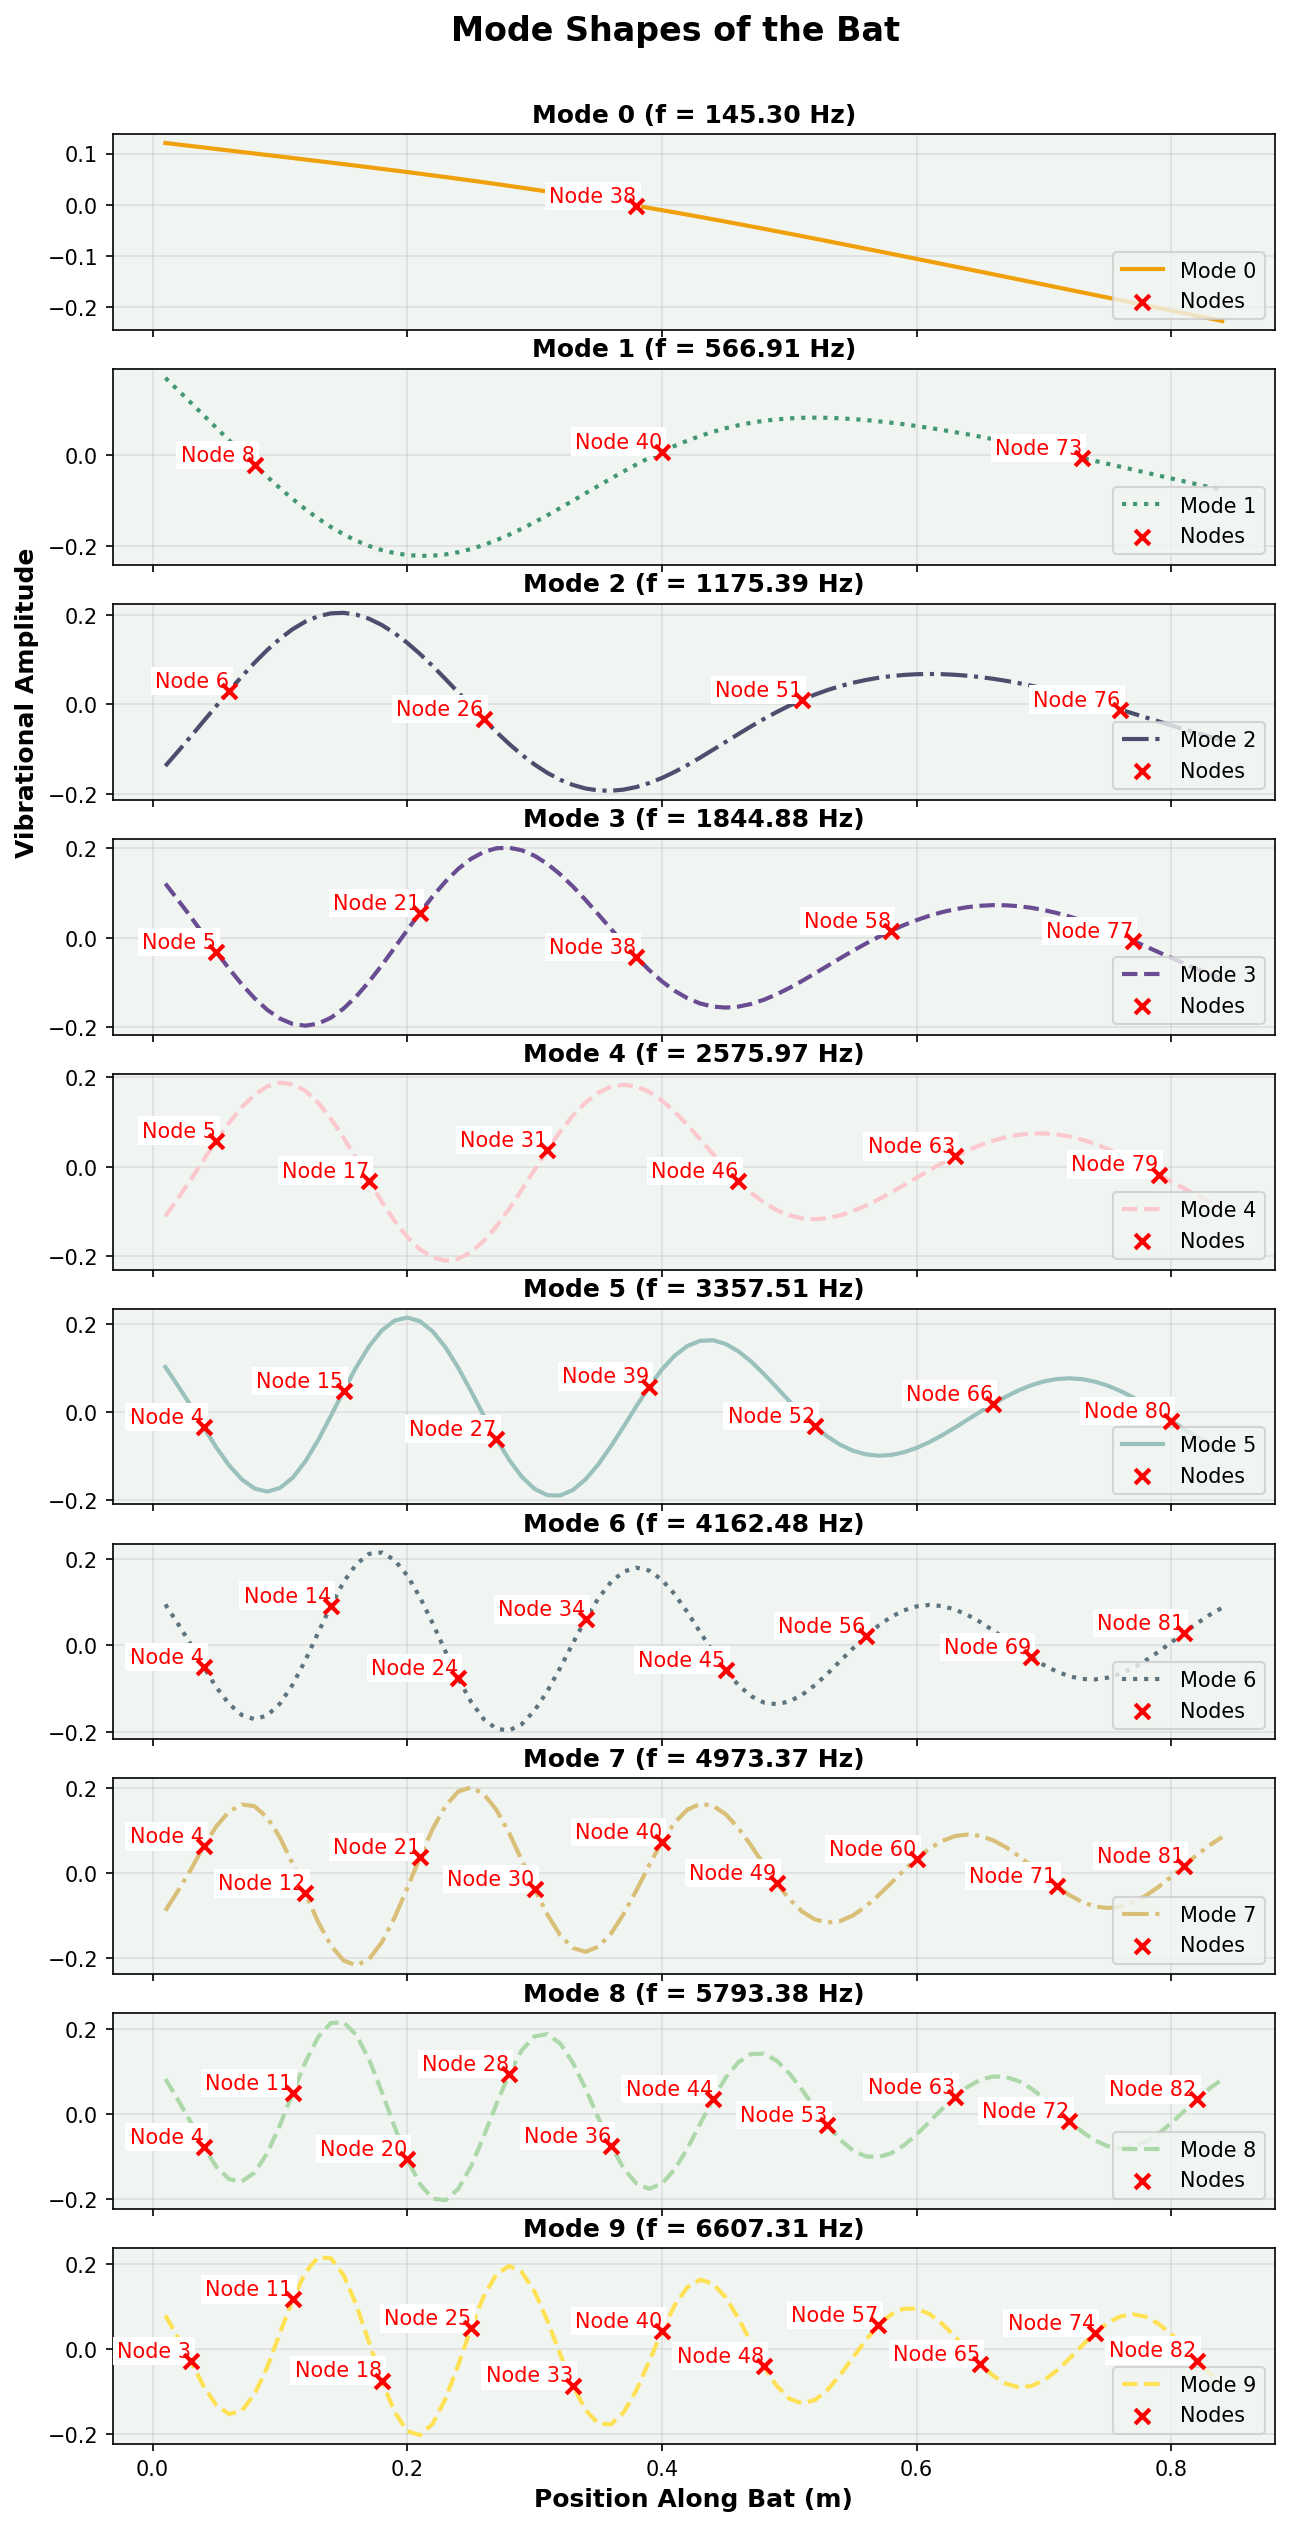

In [ ]:
# shapes of the modes
ls = ['-', ':', '-.', '--', '--'] * 2 
fig, axs = plt.subplots(num_modes, sharex=True, figsize=(10, 20))
for i in range(num_modes):
    axs[i].plot(standard_bat.zs, evecs[:, i].real[:standard_bat.N], label=f'Mode {i}', color=colors[i], linestyle = ls[i])
    axs[i].scatter(standard_bat.zs[nodes[i]], evecs[nodes[i], i].real,  s=50, marker='x', color = 'r', zorder = 20, label='Nodes')
    for node in nodes[i]:
        axs[i].text(standard_bat.zs[node], evecs[node, i].real, f'Node {node+1}', color='r', fontsize=10, ha='right', va='bottom', bbox =dict(facecolor='white', edgecolor='none', pad=2),)
    axs[i].legend(loc = 'lower right')
    axs[i].set_title(f'Mode {i} (f = {omega[i]:.2f} Hz)', fontweight='bold', fontsize=12)
axs[-1].set_xlabel('Position Along Bat (m)')
axs[2].set_ylabel('Vibrational Amplitude')

fig.suptitle('Mode Shapes of the Bat', fontweight = 'bold', fontsize = 16, y = 0.92)
plt.show()

We create the matrix $V$ with the columns corresponding to the eigenvectors of $H$. Then, if the eigenvectors form an orthonormal basis, we expect $V^\dagger V \approx I$

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
/var/folders/9b/gcnbw5016f10hn50pnxmd2t40000gn/T/ipykernel_69744/2037974891.py:6: SyntaxWarning: invalid escape sequence '\d'
  plt.title("Result of $V^{\dagger} V$\n(should be close to identity)")


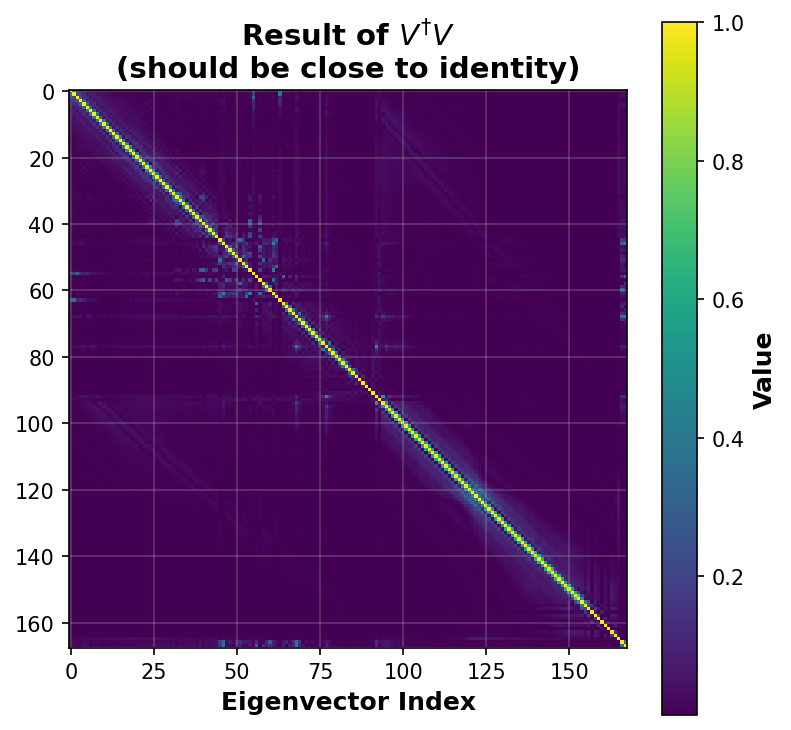

In [254]:
evecs = evecs / np.linalg.norm(evecs, axis=0) # normalize eigenvectors to have unit length (orthonormalize)
## orthogonality of eigenvectors
orth = evecs.T.conj() @ evecs

plt.figure(figsize=(6, 6))
plt.title("Result of $V^{\dagger} V$\n(should be close to identity)")
plt.imshow(np.abs(orth), cmap='viridis')
plt.colorbar(label='Value')
plt.xlabel('Eigenvector Index')
plt.show()

Remove unstable modes

In [ ]:
paired = sorted(zip(evals, evecs))
evals, evecs = zip(*paired)
evals = np.array(evals)
evecs = np.array(evecs)
unstable = evals > 0
stable   = evals < 0
print("Number of unstable modes:", np.sum(unstable))
print("Number of stable modes:", np.sum(stable))

selected_modes = 50

V_stable = evecs[:, stable]
evals_stable = evals[stable]

#first 50 modes
evecs_selected = V_stable[:, -50:]
evals_selected = evals_stable[-50::-1]

psi0_proj = V_stable @ (V_stable.T @ psi0[:2*standard_bat.N]) # project initial conditions onto stable subspace
print("Norm of original initial conditions:", np.linalg.norm(psi0))
print("Norm of projected initial conditions:", np.linalg.norm(psi0_proj))
psi0_new = np.concatenate((psi0_proj, np.zeros_like(psi0_proj))) # set velocity components to zero

H_filtered = V_stable @ np.diag(evals_stable) @ V_stable.T



Number of unstable modes: 2
Number of stable modes: 166
Norm of original initial conditions: 0.0001
Norm of projected initial conditions: 0.0001312515061055697


In [260]:
new_evals = np.linalg.eigvals(H_filtered)
new_evals.sort()

new_evals = np.sqrt(-new_evals) / (2 * np.pi) # convert to frequencies in Hz
print("New eigenvalues after filtering:", new_evals[-10::-1]) # print the first

New eigenvalues after filtering: [  1615.76879411   1881.70962267   2146.06030261   2403.58567382
   2667.33791983   2931.61728012   3200.27721283   3473.19460824
   3755.77426176   4053.69539271   4369.05194719   4716.98808306
   5111.65148634   5554.52701506   6045.48180089   6518.82051781
   6995.94376011   7575.0571838    8220.19459256   9007.07829935
   9936.73375104  10808.67771689  11761.31566045  12772.18073609
  13782.00949002  14935.69440342  16007.08687683  17123.10029663
  17454.20920534  18366.66131072  19500.67407258  20664.51498233
  20848.89051834  21271.51163306  21781.59145461  22059.71441655
  22217.54996856  22355.18285559  22440.26509059  22738.04550888
  22971.80063355  23266.72383469  23546.45529809  23830.85497562
  24486.15376211  25235.60188168  25403.45519831  26226.85754299
  26721.32745367  27678.87159652  27887.61967419  29214.42142047
  29373.03801268  30365.32117279  31009.4834515   31868.69691969
  32385.4829718   32674.36792535  32692.08795498  33310.6

/var/folders/9b/gcnbw5016f10hn50pnxmd2t40000gn/T/ipykernel_69744/2583125816.py:4: RuntimeWarning: invalid value encountered in sqrt
  new_evals = np.sqrt(-new_evals) / (2 * np.pi) # convert to frequencies in Hz


In [ ]:

## integrate the system using the filtered H matrix
stability = True
if stability:
    standard_bat.H = H_filtered
    standard_bat.set_initial_conditions(psi0_new)


### Integrate Solution ### 

In [ ]:
sol = standard_bat.integrate_solution((0, end_t), t_eval)

In [263]:
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  5.001e-05 ...  4.999e-01  5.000e-01]
        y: [[ 2.866e-07 -1.917e-06 ... -1.214e-05  5.779e-06]
            [ 1.199e-06 -1.244e-06 ...  3.584e-06 -1.767e-06]
            ...
            [ 0.000e+00  1.211e-02 ... -1.721e+00 -2.398e+00]
            [ 0.000e+00 -1.155e-01 ... -9.130e-01 -2.141e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 15843026
     njev: 0
      nlu: 0

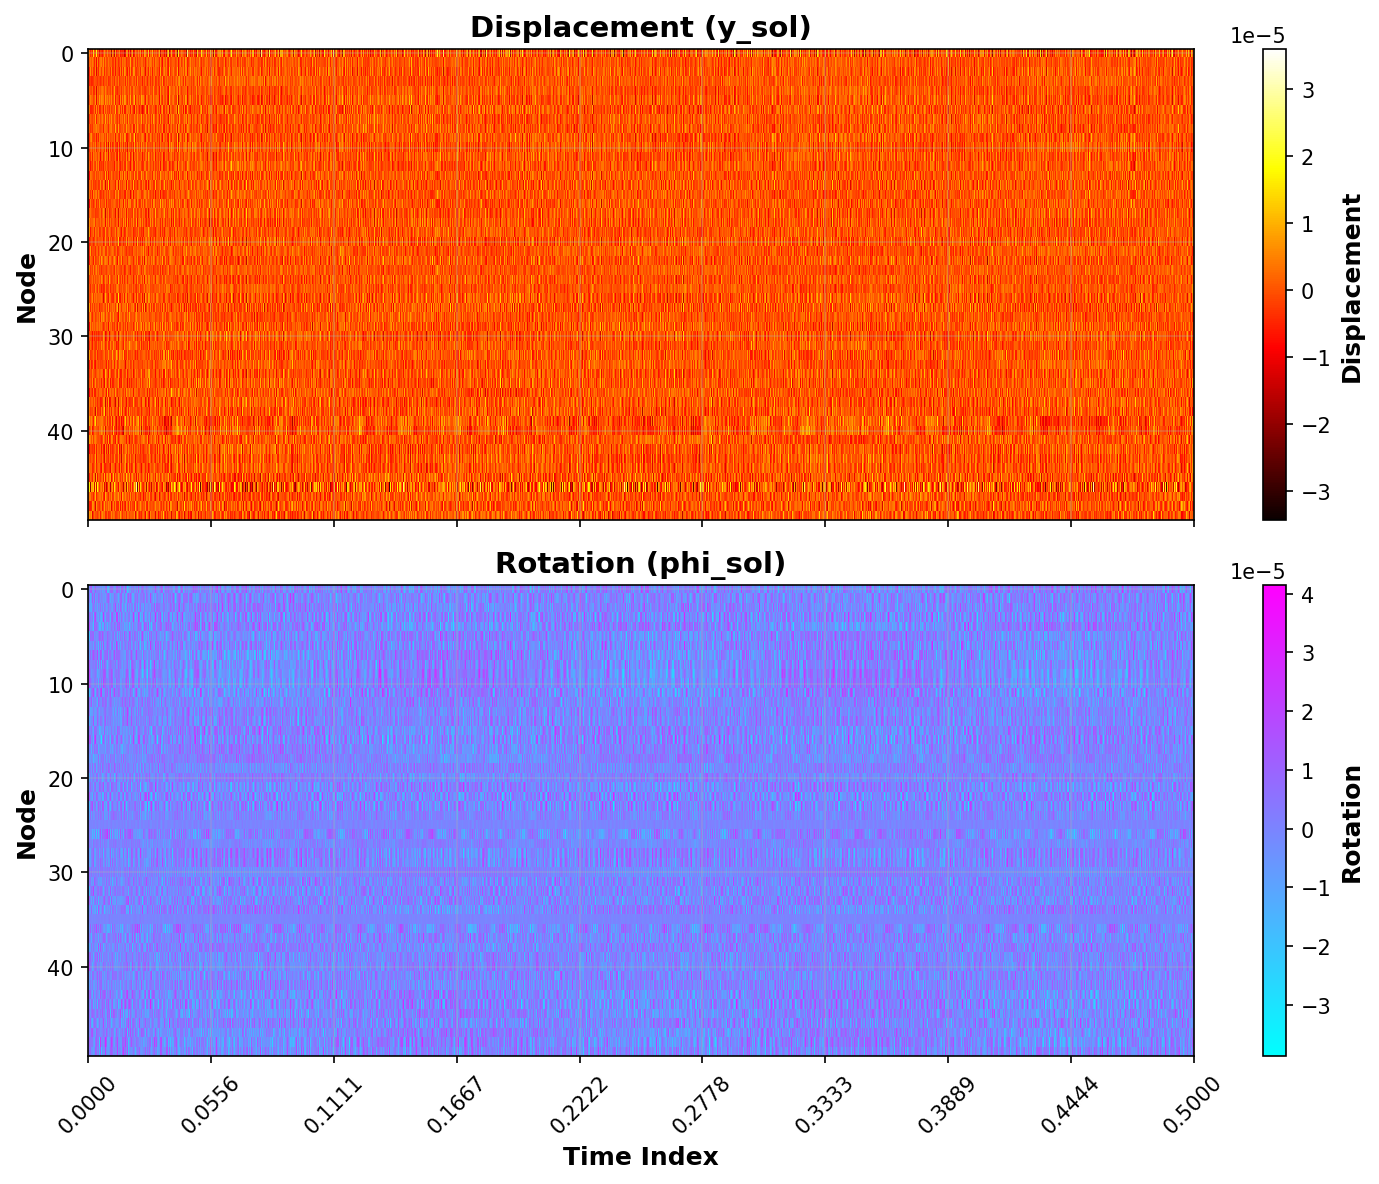

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
# y_sol subplot
im0 = axs[0].imshow(standard_bat.y_sol[:50], cmap='hot', interpolation='nearest', aspect='auto')
axs[0].set_ylabel('Node')
axs[0].set_title('Displacement (y_sol)')
plt.colorbar(im0, ax=axs[0], label='Displacement')
# phi_sol subplot
im1 = axs[1].imshow(standard_bat.phi_sol[:50], cmap='cool', interpolation='nearest', aspect='auto')
axs[1].set_xlabel('Time Index')
axs[1].set_ylabel('Node')
axs[1].set_title('Rotation (phi_sol)')
plt.colorbar(im1, ax=axs[1], label='Rotation')
# Set x-ticks to correspond to time points in standard_bat.t
num_ticks = 10
if hasattr(standard_bat, 't') and len(standard_bat.t) > 1:
    xtick_locs = np.linspace(0, len(standard_bat.t)-1, num_ticks, dtype=int)
    xtick_labels = [f"{standard_bat.t[i]:.4f}" for i in xtick_locs]
    axs[1].set_xticks(xtick_locs)
    axs[1].set_xticklabels(xtick_labels, rotation=45)
plt.tight_layout()
plt.show()

### Fourier

First, compute the expected frequencies from the H matrix

In [266]:
## print H matrix eigenvalues
H = load_H_matrix('data/H_matrix_Alan.csv')
H = -H

eigenvalues, _ = np.linalg.eig(H)
omega = np.sqrt(-eigenvalues) / (2 * np.pi) # convert to frequencies in Hz

Alan_freqs = [165, 586, 1177, 1851, 2580, 3359, 4163, 4972, 5783, 6598]
#sort omega
omega = np.sort(omega)



print("First 10 frequencies of H matrix, Hz:")
print(omega[:10])
print("Alan's frequencies, Hz:")
print(Alan_freqs)

#divide component-wise by Alan's frequencies to get relative error
rel_error = np.abs((omega[:10] - np.array(Alan_freqs)) / np.array(Alan_freqs))
print("Relative error:")
print(rel_error)


KeyboardInterrupt: 

In [ ]:
dt = standard_bat.t[1] - standard_bat.t[0]
print(f"Time step used in integration: {dt} seconds")
nyquist = 1 / (2 * dt)
print(f"Nyquist frequency: {nyquist} Hz")

Time step used in integration: 5.000500050005001e-05 seconds
Nyquist frequency: 9999.0 Hz


In [ ]:
# %% Fourier
bat_fft = np.fft.fft(standard_bat.y_sol, axis=1) #take fft along time axis
ntime = len(standard_bat.t) 
freqs = np.fft.fftfreq(ntime, d= standard_bat.t[1] - standard_bat.t[0]) #frequency bins corresponding to FFT components

# Compute amplitude spectrum
amplitude = np.abs(bat_fft[:, 0:ntime//2])
freqs_pos = freqs[0:ntime//2] #positive frequencies


# Average amplitude across all nodes
mean_amplitude = amplitude.mean(axis=0)


freqs_pos_mask = freqs_pos < 1000 #only look at frequencies below 1000 Hz
new_freqs = freqs_pos[freqs_pos_mask]
mean_amplitude = mean_amplitude[freqs_pos_mask]

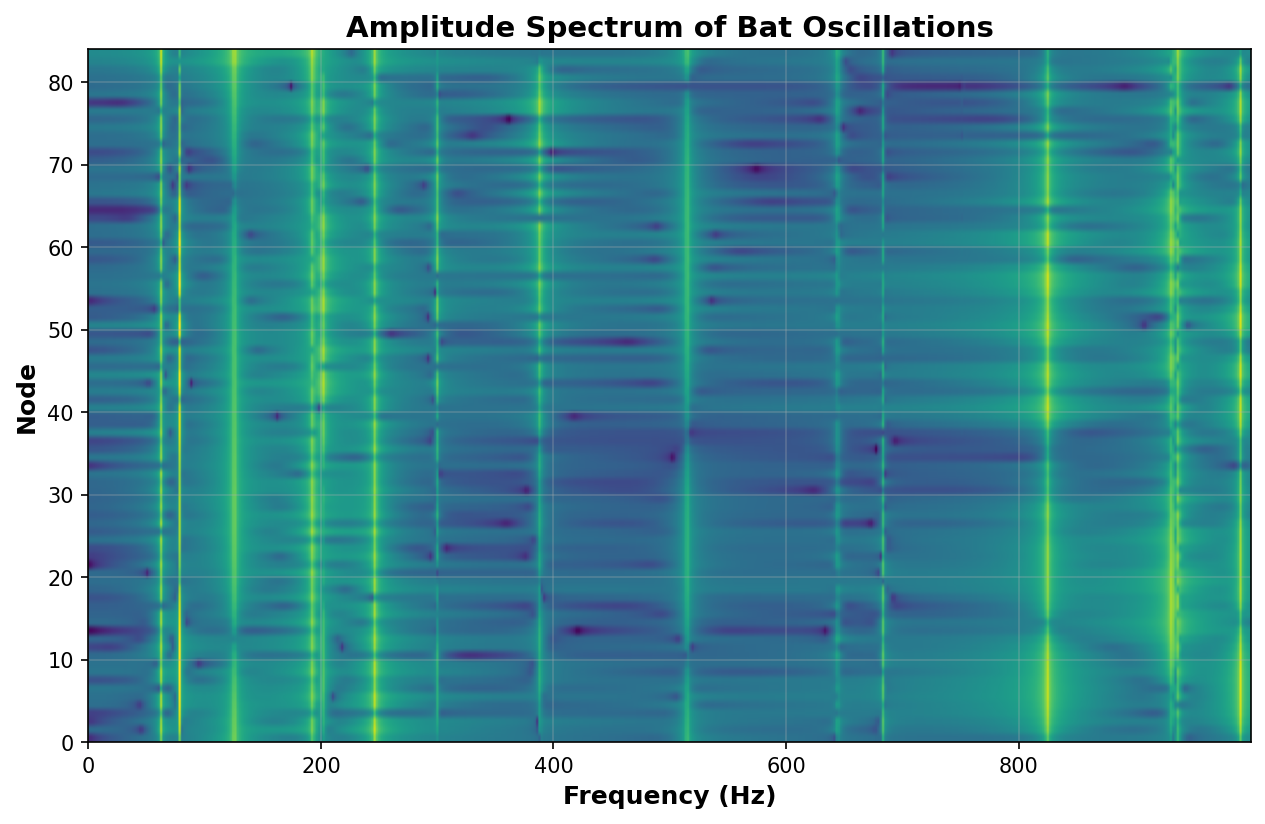

In [ ]:
# Plot the fft
cmap = plt.get_cmap('viridis').colors[:len(amplitude)] # get a subset of the colormap for the number of frequencies

log_amp = np.log10(amplitude + 1e-10) # add small value to avoid log(0)
plt.imshow(log_amp[:, freqs_pos_mask], extent=(new_freqs[0], new_freqs[-1], 0, amplitude.shape[0]), aspect='auto', cmap='viridis')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Node')
plt.title('Amplitude Spectrum of Bat Oscillations')
plt.show()

In [ ]:
#find peaks in the residuals 
peaks, _ = find_peaks(mean_amplitude) # only consider peaks with height > 5%
print("Significant peaks in spectrum at frequencies (Hz):")
for peak in peaks:
    print(f"{new_freqs[peak]:.2f} Hz with amplitude {mean_amplitude[peak]:.4f}")

centroids = []
print("Centroid frequencies of significant peaks (Hz):")
for peak in peaks:
    # Define a window around the peak for centroid calculation
    window = 5  # number of points on each side
    left = max(peak - window, 0)
    right = min(peak + window + 1, len(mean_amplitude))
    amp_window = mean_amplitude[left:right]
    freq_window = new_freqs[left:right]
    # Centroid calculation (center of mass)
    centroid = np.sum(freq_window * amp_window) / np.sum(amp_window)
    centroids.append(centroid)
    print(f"Peak at {new_freqs[peak]:.2f} Hz, centroid: {centroid:.2f} Hz, amplitude: {mean_amplitude[peak]:.4f}")
centroids = np.array(centroids)

Significant peaks in spectrum at frequencies (Hz):
61.99 Hz with amplitude 0.0026
77.99 Hz with amplitude 0.0091
125.99 Hz with amplitude 0.0010
191.98 Hz with amplitude 0.0020
201.98 Hz with amplitude 0.0014
245.98 Hz with amplitude 0.0028
299.97 Hz with amplitude 0.0005
387.96 Hz with amplitude 0.0009
515.95 Hz with amplitude 0.0004
643.94 Hz with amplitude 0.0001
683.93 Hz with amplitude 0.0004
825.92 Hz with amplitude 0.0038
931.91 Hz with amplitude 0.0017
937.91 Hz with amplitude 0.0015
991.90 Hz with amplitude 0.0046
Centroid frequencies of significant peaks (Hz):
Peak at 61.99 Hz, centroid: 62.02 Hz, amplitude: 0.0026
Peak at 77.99 Hz, centroid: 77.96 Hz, amplitude: 0.0091
Peak at 125.99 Hz, centroid: 125.39 Hz, amplitude: 0.0010
Peak at 191.98 Hz, centroid: 194.81 Hz, amplitude: 0.0020
Peak at 201.98 Hz, centroid: 197.98 Hz, amplitude: 0.0014
Peak at 245.98 Hz, centroid: 246.08 Hz, amplitude: 0.0028
Peak at 299.97 Hz, centroid: 299.97 Hz, amplitude: 0.0005
Peak at 387.96 Hz, ce

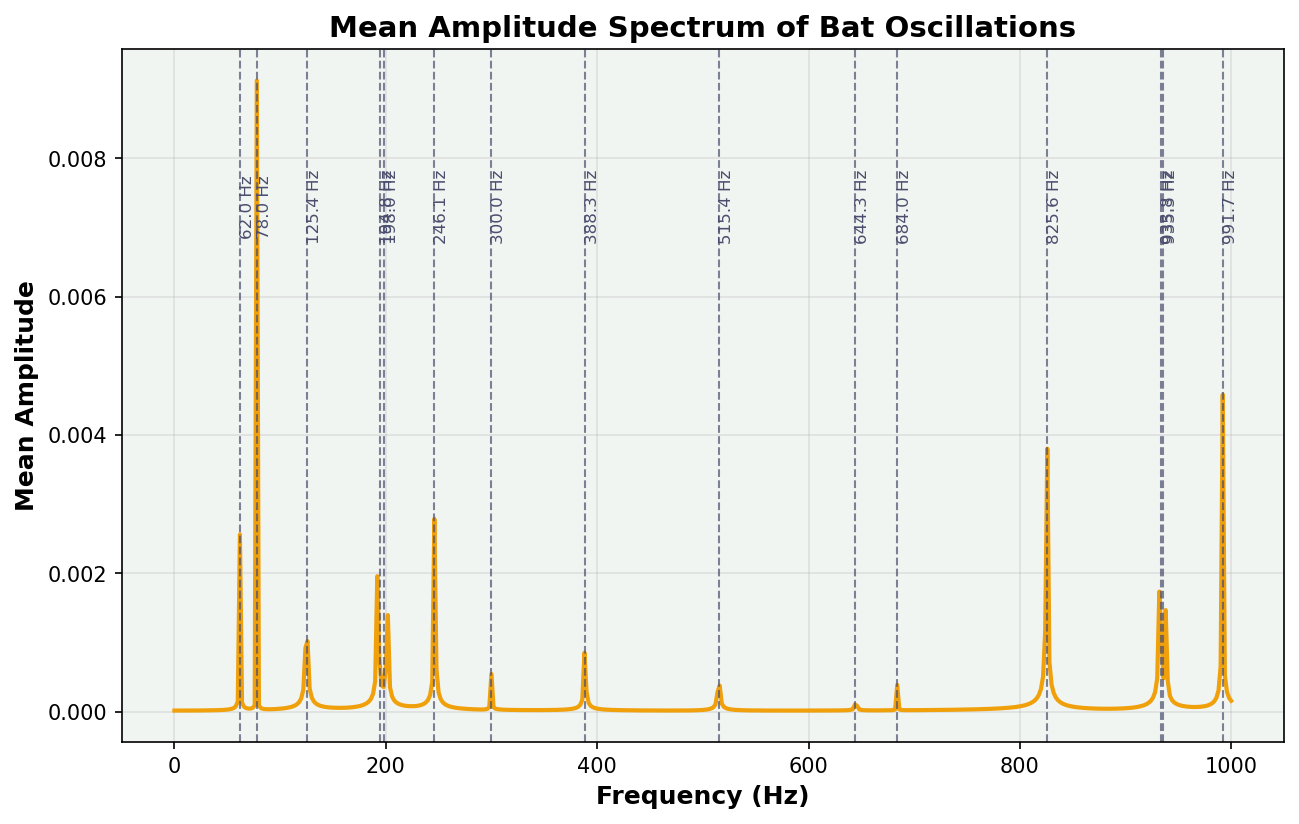

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(new_freqs, mean_amplitude, label='Mean Amplitude Spectrum', color = colors[0])
for centroid in centroids:
    plt.axvline(x=centroid, color=colors[2], linestyle='--', alpha=0.7, label=f'Centroid: {centroid:.2f} Hz', linewidth = 1)
    plt.text(centroid, max(mean_amplitude)*0.8, f'{centroid:.1f} Hz', rotation=90, verticalalignment='center', color=colors[2], fontsize=8)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Mean Amplitude')
plt.title('Mean Amplitude Spectrum of Bat Oscillations')
plt.show()

## Animate

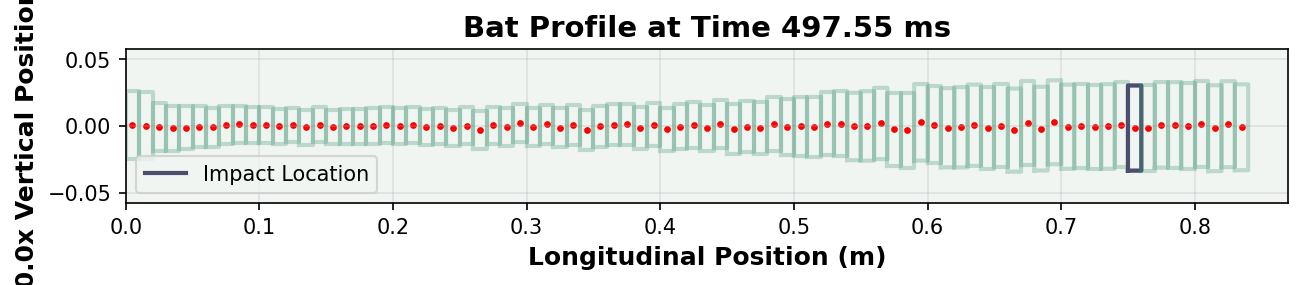

In [ ]:
standard_bat.animate_bat(exaggerate=500.0, interval=50, path = f'plots/collision_at_{impact_idx}.mp4', idx = impact_idx)

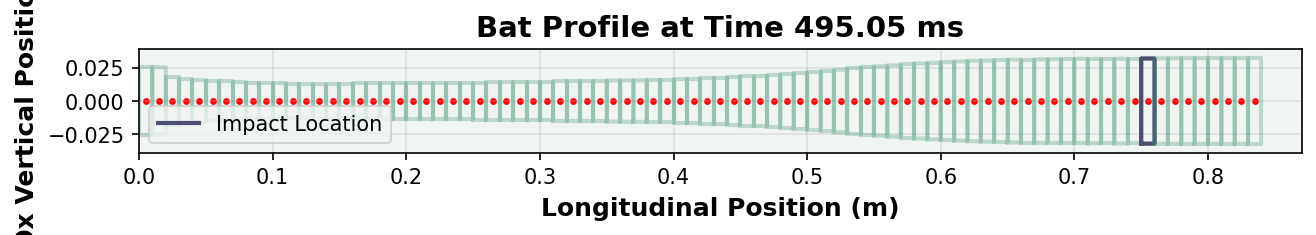

In [ ]:
standard_bat.animate_bat(exaggerate=10.0, interval=100, path = f'plots/collision_at_{impact_idx}_10x.mp4', idx = impact_idx)

## Colliding bat

In [92]:
col_bat = BatOsc(bat_prof, 0.01)
col_bat.set_bat_features(mass, rho, Y, S) # in kg, kg/m^3, N/m^2, N/m^2, setting the bat features for integration

In [93]:
# inits
y0 = np.zeros(col_bat.N)
Phi0 = np.zeros(col_bat.N)
dy0 = np.zeros(col_bat.N)
dPhi0 = np.zeros(col_bat.N)

psi0 = np.concatenate((y0, Phi0, dy0, dPhi0))
col_bat.set_initial_conditions(psi0)
col_bat.get_H_matrix('data/H_matrix_Alan.csv')

In [94]:
# force profile for collision
def force_profile_gaus(t, slice):
    if not isinstance(t, np.ndarray):
        t = np.array([t])
        print(t.shape)
    F = np.zeros((2*col_bat.N, t.shape[0]))
    print(F.shape)
    # Simple Gaussian force profile centered at 4 ms with a width of 0.5 ms and a peak force of 1000 N
    F_peak = 15000  # Peak force in Newtons
    t_center = 0.004  # Center time of the collision in seconds
    width = 0.0005  # Width of the force profile in seconds
    F[slice] = F_peak * np.exp(-0.5 * ((t - t_center) / width)**2)
    return F

In [95]:
def F_constant(t, t_max, slice, mag):
    if not isinstance(t, np.ndarray):
        t = np.array([t])
    F_array = np.zeros((2*col_bat.N, len(t)))
    for i, time in enumerate(t):
        if time <= t_max:
            F_array[slice, i] = mag
    return F_array

In [96]:
F = lambda t: F_constant(t, 0.001, 75, -10000) # be careful about the max time -> no more than 1ms

end_t = 0.008 # end time for integration in seconds
t_eval = np.linspace(0, end_t, 10000) # time evaluation points for integration

sol = col_bat.integrate_solution_with_collision((0, end_t), F, t_eval)

In [97]:
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  8.001e-07 ...  7.999e-03  8.000e-03]
        y: [[ 0.000e+00  0.000e+00 ...  3.202e-02  3.204e-02]
            [ 0.000e+00  0.000e+00 ...  3.120e-02  3.122e-02]
            ...
            [ 0.000e+00  0.000e+00 ...  1.045e+00  1.045e+00]
            [ 0.000e+00  0.000e+00 ...  1.045e+00  1.045e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 54176
     njev: 0
      nlu: 0

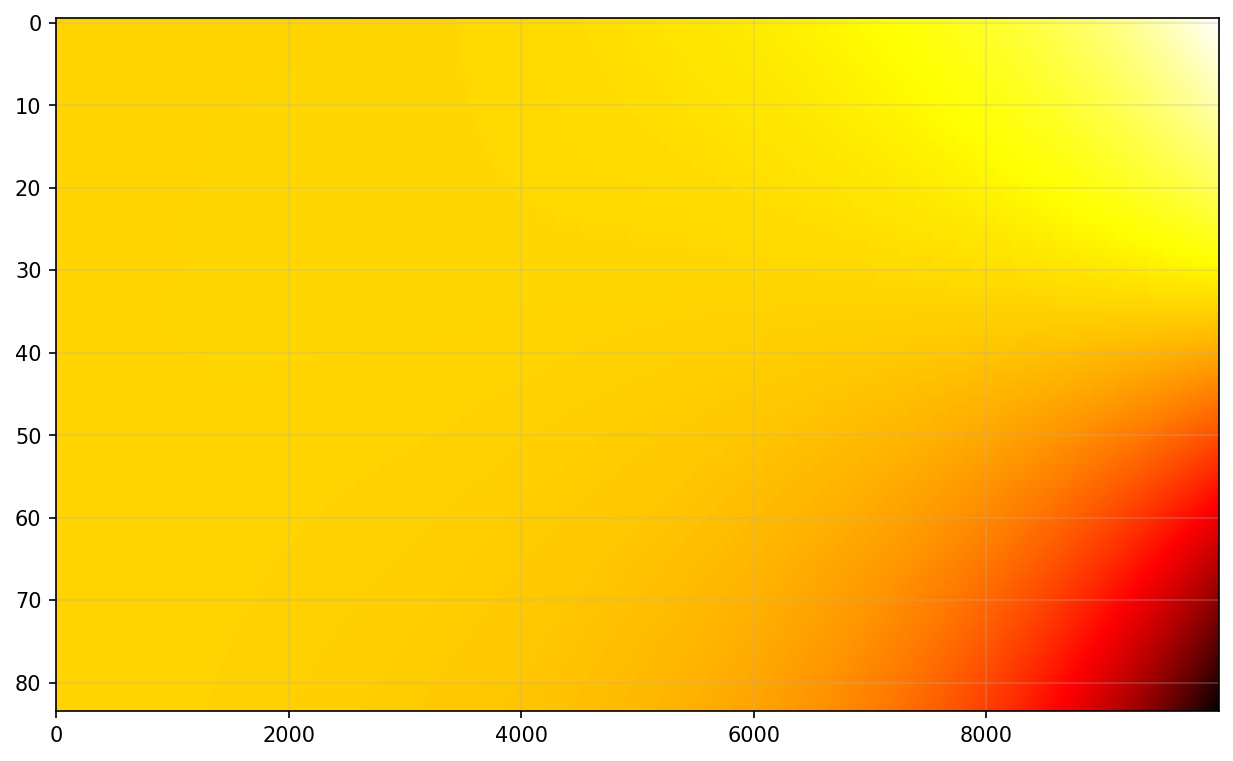

In [98]:
plt.imshow(col_bat.y_sol, aspect='auto', cmap='hot')